In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import scipy.stats as st
from statsmodels.stats.proportion import proportion_confint

print("Hello, world")

Hello, world


In [105]:
df_orders = pd.read_csv('../analytical-report/data/FACT_Orders.csv')
df_delivery = pd.read_csv('../analytical-report/data/DIM_Delivery.csv')
df_customer = pd.read_csv('../analytical-report/data/DIM_Customer.csv')
df_shopping = pd.read_csv('../analytical-report/data/DIM_Shopping.csv')
df_products = pd.read_csv('../analytical-report/data/DIM_Products.csv')


In [106]:
df_orders_kpi = df_orders[['Id', 'Discount', 'Subtotal', 'Purchase_Status']]
df_shopping_kpi = df_shopping[['Id', 'Quantity']]

df_elasticity = pd.merge(df_orders_kpi, df_shopping_kpi, on='Id', how='inner')


In [107]:
df_shopping['Product_Key'] = df_shopping['Item_ID'].str.split(',').str[1]

df_products['Product_Key'] = df_products['Product_Id'].str.split(',').str[1]

In [108]:
df_orders_agg = df_orders.groupby('Id').agg(
    Order_Date=('Order_Date', 'first'),
    payment=('Payment', 'first'),
    Purchase_Status=('Purchase_Status', 'first'),

    Subtotal=('Subtotal', 'sum'),
    Discount=('Discount', 'sum'),
    Total=('Total', 'sum')
).reset_index()

print(df_orders_agg.head())

   Id           Order_Date  payment Purchase_Status  Subtotal  Discount  \
0   1  2025-04-12 00:52:33  Credito     Processando   3958.20    0.1048   
1   2  2025-05-05 01:02:38      PIX      Em Analise   1799.01    0.1141   
2   3  2025-04-27 23:05:38   Boleto       Cancelado   2144.00    0.0686   
3   4  2025-04-10 02:42:52   Debito     Processando    199.60    0.0264   
4   5  2025-05-12 21:55:33  Credito      Em Analise    161.70    0.0697   

     Total  
0  3586.28  
1  1636.64  
2  2019.82  
3   237.23  
4   193.33  


In [109]:
df_abt = df_orders_agg.copy()

df_delivery_clean = df_delivery[['Id', 'Services', 'P_Sevice', 'D_Forecast', 'D_Date', 'Status']]
df_abt = pd.merge(df_abt, df_delivery_clean, on='Id', how='left')

df_customer_clean = df_customer[['Id', 'State', 'Region']]
df_abt = pd.merge(df_abt, df_customer_clean, on='Id', how='left')

df_abt = df_abt.rename(columns={
    'Id': 'order_id',
    'Order_Date': 'Order_Date',
    'payment': 'Payment_Method',
    'Purchase_Status': 'Purchase_Status',
    'Services': 'Service',
    'P_Sevice': 'P_Service', 
    'D_Forecast': 'D_Forecast',
    'D_Date': 'D_Date',
    'Status': 'Delivery_Status',
    'State': 'UF',
    'Region': 'Region'
})

In [110]:
df_items_base = df_shopping[['Id', 'Product_Key', 'Quantity', 'Price']]

df_products_clean = df_products[['Product_Key', 'Product_Name', 'Category', 'Subcategory']]
df_items_abt = pd.merge(df_items_base, df_products_clean, on='Product_Key', how='left')

df_items_abt = pd.merge(
    df_items_abt,
    df_orders_agg[['Id', 'Order_Date']],
    on='Id',
    how='left'
)

In [111]:
date_cols = ['Order_Date', 'D_Date', 'D_Forecast']
for col in date_cols:
    df_abt[col] = pd.to_datetime(df_abt[col], errors='coerce')

numeric_cols = ['Subtotal', 'Discount', 'Total', 'P_Service']
for col in numeric_cols:
    df_abt[col] = pd.to_numeric(df_abt[col], errors='coerce')


#  2. Limpeza de Strings

string_cols = ['Payment_Method', 'Purchase_Status', 'Service', 'Delivery_Status', 'UF', 'Region']
for col in string_cols:
    df_abt[col] = df_abt[col].astype(str).str.lower().str.strip()

df_abt = df_abt.replace('nan', np.nan)


# 3. Tratamento de Nulos (NA) 

# Para NAs numéricos (Subtotal, Discount, etc.), assumimos que 0 é
# o valor correto (ex: um pedido sem desconto terá NA do merge)
df_abt[numeric_cols] = df_abt[numeric_cols].fillna(0)

# Verificar integridade: Pedidos com Total 0
total_zero = (df_abt['Total'] == 0).sum()
print(f"Encontrados {total_zero} pedidos com Total R$ 0.00. (Revisar se necessário)")


# 4. Verificação de Duplicatas e Integridade 
dups = df_abt['order_id'].duplicated().sum()
if dups > 0:
    print(f"ALERTA: Encontradas {dups} duplicatas em 'order_id'. Removendo...")
    df_abt = df_abt.drop_duplicates(subset='order_id', keep='first')
else:
    print("Verificação de duplicatas: OK. 'order_id' é uma chave única.")

# Verificar integridade de datas (ex: entrega antes do pedido)
erros_data = (df_abt['D_Date'] < df_abt['Order_Date']).sum()
if erros_data > 0:
    print(f"ALERTA: Encontrados {erros_data} pedidos com data de entrega ANTES da data do pedido. (Revisar dados)")

print("\n--- Limpeza de Dados Concluída ---")
df_abt.info()

Encontrados 0 pedidos com Total R$ 0.00. (Revisar se necessário)
Verificação de duplicatas: OK. 'order_id' é uma chave única.
ALERTA: Encontrados 328 pedidos com data de entrega ANTES da data do pedido. (Revisar dados)

--- Limpeza de Dados Concluída ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         2000 non-null   int64         
 1   Order_Date       2000 non-null   datetime64[ns]
 2   Payment_Method   2000 non-null   object        
 3   Purchase_Status  2000 non-null   object        
 4   Subtotal         2000 non-null   float64       
 5   Discount         2000 non-null   float64       
 6   Total            2000 non-null   float64       
 7   Service          2000 non-null   object        
 8   P_Service        2000 non-null   float64       
 9   D_Forecast       2000 non-null   datetime64[ns]
 1

In [112]:
print("\n--- Iniciando Feature Engineering ---")

# 1. KPIs de Logística

df_entregues = df_abt[(df_abt['Delivery_Status'].isin(['entregue', 'atrasado'])) & (df_abt['D_Date'].notna())].copy()

if df_entregues.empty:
    print("ALERTA: Nenhum pedido encontrado com status 'entregue' ou 'atrasado'. A análise logística será pulada.")
else:
    # Tempo do pedido até a entrega
    df_entregues['delivery_lead_time_days'] = (df_entregues['D_Date'] - df_entregues['Order_Date']).dt.days

    # Atraso na entrega: Diferença da entrega vs. previsão
    # Negativo = chegou adiantado. Positivo = chegou atrasado.
    df_entregues['delivery_delay_days'] = (df_entregues['D_Date'] - df_entregues['D_Forecast']).dt.days

    # Flag de Atraso (KPI): 1 se atrasou, 0 se chegou no dia ou antes
    df_entregues['is_late'] = (df_entregues['delivery_delay_days'] > 0).astype(int)
    
    print(f"{len(df_entregues)} pedidos foram considerados 'entregues' para análise logística.")




--- Iniciando Feature Engineering ---
1009 pedidos foram considerados 'entregues' para análise logística.


In [113]:

# 2. KPIs de Negócio e Financeiros (na base principal df_abt)

# Flags de Status (KPIs de Conversão)
# (Baseado nos valores que vimos: 'confirmado', 'cancelado', 'em analise', 'processando')
df_abt['is_confirmed'] = (df_abt['Purchase_Status'] == 'confirmado').astype(int)
df_abt['is_canceled'] = (df_abt['Purchase_Status'] == 'cancelado').astype(int)

# KPIs Financeiros (KPIs de Rentabilidade)
# Take-rate de Frete: Quanto do Total do pedido é composto pelo frete
df_abt['freight_share'] = np.where(
    df_abt['Total'] > 0,
    df_abt['P_Service'] / df_abt['Total'],
    0
)

# % de Desconto
df_abt['discount_perc'] = np.where(
    df_abt['Subtotal'] > 0,
    df_abt['Discount'] / df_abt['Subtotal'],
    0
)


In [130]:
df_elasticity['discount_perc'] = df_elasticity['Discount']

# Limpar o status de compra (padrão da Fase 2.1)
df_elasticity['Purchase_Status'] = df_elasticity['Purchase_Status'].astype(str).str.lower().str.strip()


# --- 3. Binning (Agrupamento) do Desconto ---

# Filtra apenas por vendas confirmadas
df_analise = df_elasticity[df_elasticity['Purchase_Status'] == 'confirmado'].copy()

# Definir as faixas de desconto
# (Ajuste os 'bins' se seus descontos forem diferentes)
bins = [-0.01, 0, 0.05, 0.1, 0.15, 0.2, 1] 
labels = ['0% (Sem Desconto)', '0.1% a 5%', '5.1% a 10%', '10.1% a 15%', '15.1% a 20%', '> 20%']

# Criar a coluna 'faixa_desconto'
df_analise['faixa_desconto'] = pd.cut(
    df_analise['discount_perc'], 
    bins=bins, 
    labels=labels,
    right=True # Inclui o valor mais alto (ex: 5% cai em '0.1% a 5%')
)

# Tratar casos que não caíram em nenhuma faixa (se houver)
df_analise = df_analise.dropna(subset=['faixa_desconto'])


# --- 4. Calcular o KPI ---
# Agrupamos pela faixa de desconto e calculamos a QUANTIDADE MÉDIA vendida
kpi_elasticidade = df_analise.groupby('faixa_desconto', observed=True)['Quantity'].mean().reset_index()

print("KPI: Quantidade Média Vendida por Faixa de Desconto")
print(kpi_elasticidade)

KPI: Quantidade Média Vendida por Faixa de Desconto
  faixa_desconto  Quantity
0      0.1% a 5%  2.503185
1     5.1% a 10%  2.511236
2    10.1% a 15%  2.582822


In [115]:

# 3. Atributos de Sazonalidade (Agrupamento)
df_abt['order_month_year'] = df_abt['Order_Date'].dt.to_period('M') # Para séries temporais
df_abt['order_weekday'] = df_abt['Order_Date'].dt.day_name()      # Para análise de dia da semana

print("--- Feature Engineering Concluída ---")

--- Feature Engineering Concluída ---


In [116]:
print("\n--- Iniciando Análise Exploratória ---")
sns.set_style("whitegrid")



--- Iniciando Análise Exploratória ---


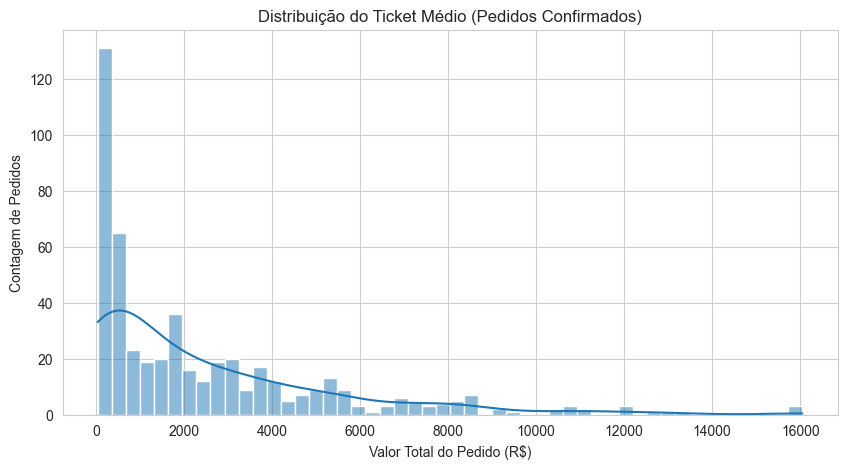

In [117]:

# 1. Análise Univariada (Distribuição dos KPIs)

# Histograma do Ticket Médio (Total)
plt.figure(figsize=(10, 5))
sns.histplot(df_abt[df_abt['is_confirmed']==1]['Total'], kde=True, bins=50)
plt.title('Distribuição do Ticket Médio (Pedidos Confirmados)')
plt.ylabel('Contagem de Pedidos')
plt.xlabel('Valor Total do Pedido (R$)')
plt.show()
# 


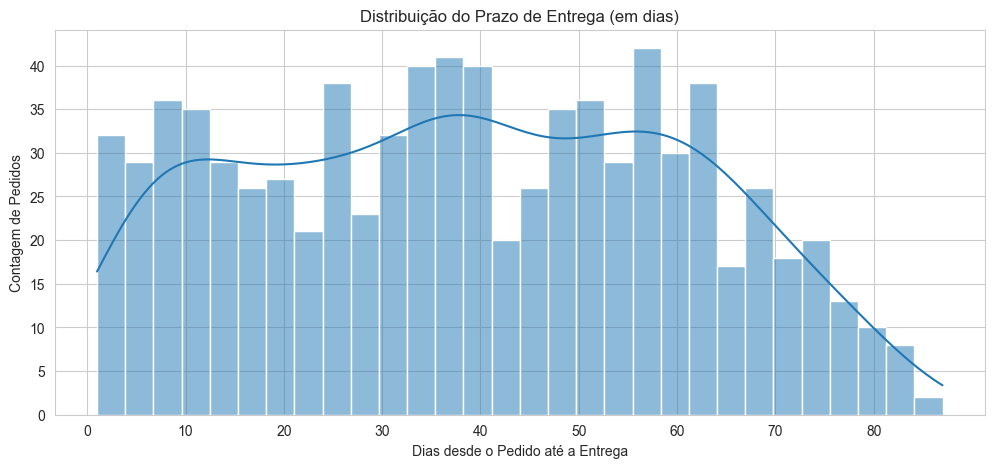

In [118]:

# Histograma do Prazo de Entrega (Lead Time)
if not df_entregues.empty:
    plt.figure(figsize=(12, 5))
    dados_filtrados = df_entregues[df_entregues['delivery_lead_time_days'] > 0]['delivery_lead_time_days']
    
    sns.histplot(dados_filtrados, kde=True, bins=30)
    plt.title('Distribuição do Prazo de Entrega (em dias)')
    plt.ylabel('Contagem de Pedidos')
    plt.xlabel('Dias desde o Pedido até a Entrega')
    plt.xticks(range(0, dados_filtrados.max(), 10))
    plt.show()


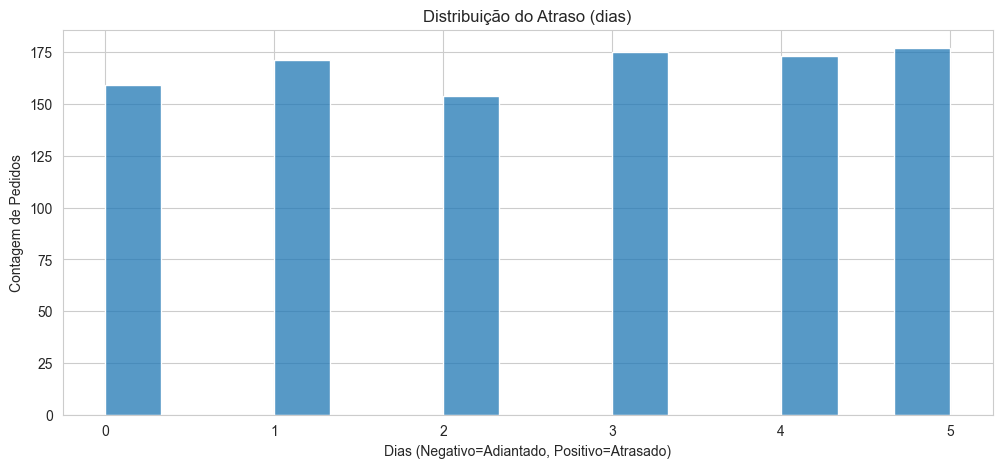

In [119]:

# Histograma do Atraso
if not df_entregues.empty:
    plt.figure(figsize=(12, 5))
    sns.histplot(df_entregues['delivery_delay_days'], kde=False, bins=15)
    plt.title('Distribuição do Atraso (dias)')
    plt.ylabel('Contagem de Pedidos')
    plt.xlabel('Dias (Negativo=Adiantado, Positivo=Atrasado)')
    plt.show()



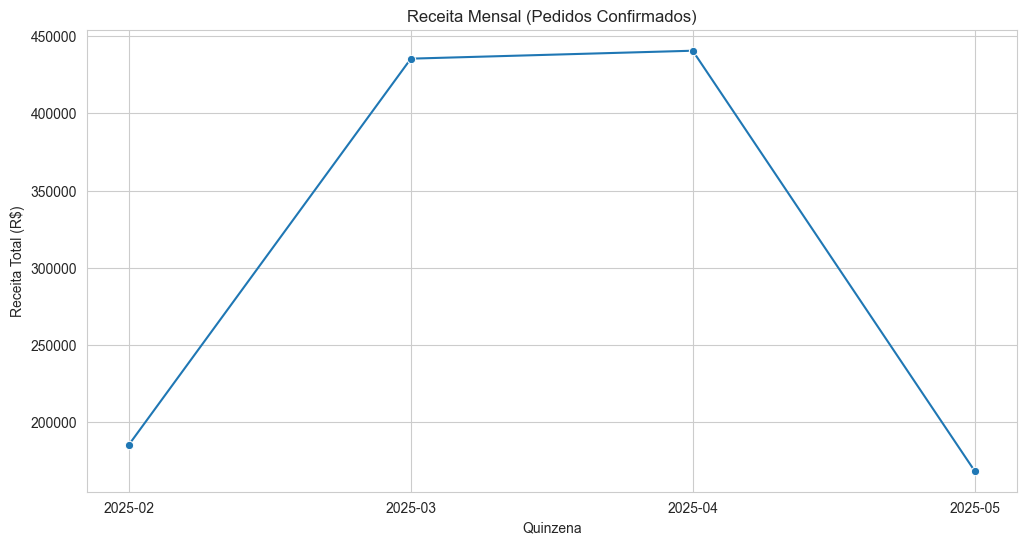

In [120]:

# 2. Análise de Sazonalidade (Séries Temporais)

# Receita (Total) ao longo do tempo
receita_mensal = df_abt[df_abt['is_confirmed']==1].groupby('order_month_year')['Total'].sum().reset_index()
receita_mensal['order_month_year_str'] = receita_mensal['order_month_year'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=receita_mensal, x='order_month_year_str', y='Total', marker="o")
plt.title('Receita Mensal (Pedidos Confirmados)')
plt.xlabel('Quinzena')
plt.ylabel('Receita Total (R$)')
plt.show()
# 


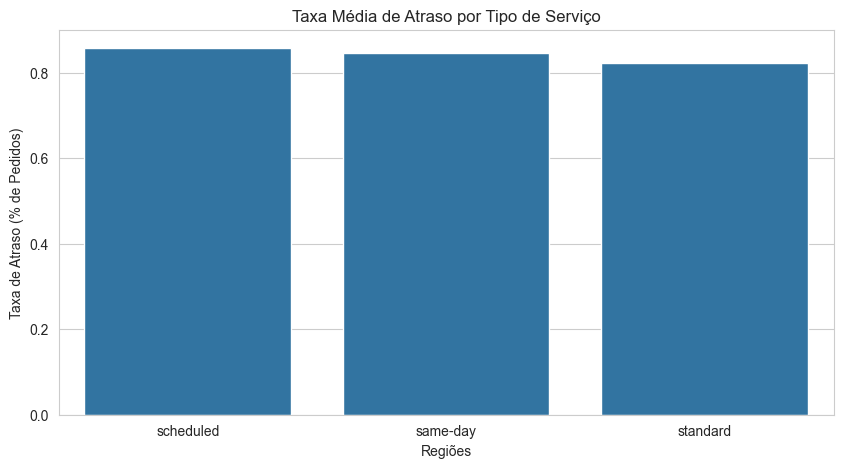

In [121]:

# 3. Análise de KPIs de Logística (Por Segmento)

# Taxa de Atraso por Serviço (Service)
if not df_entregues.empty:
    plt.figure(figsize=(10, 5))
    taxa_atraso_servico = df_entregues.groupby('Service')['is_late'].mean().reset_index()
    sns.barplot(data=taxa_atraso_servico.sort_values('is_late', ascending=False), x='Service', y='is_late')
    plt.title('Taxa Média de Atraso por Tipo de Serviço')
    plt.xlabel('Regiões')
    plt.ylabel('Taxa de Atraso (% de Pedidos)')
    plt.show()


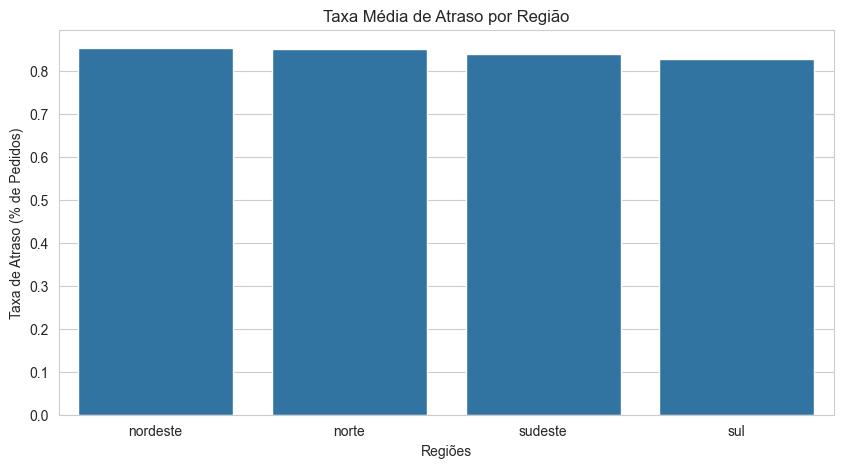

In [122]:

# Taxa de Atraso por Região (Region)
if not df_entregues.empty:
    plt.figure(figsize=(10, 5))
    taxa_atraso_regiao = df_entregues.groupby('Region')['is_late'].mean().reset_index()
    sns.barplot(data=taxa_atraso_regiao.sort_values('is_late', ascending=False), x='Region', y='is_late')
    plt.title('Taxa Média de Atraso por Região')
    plt.xlabel('Regiões')
    plt.ylabel('Taxa de Atraso (% de Pedidos)')
    plt.show()



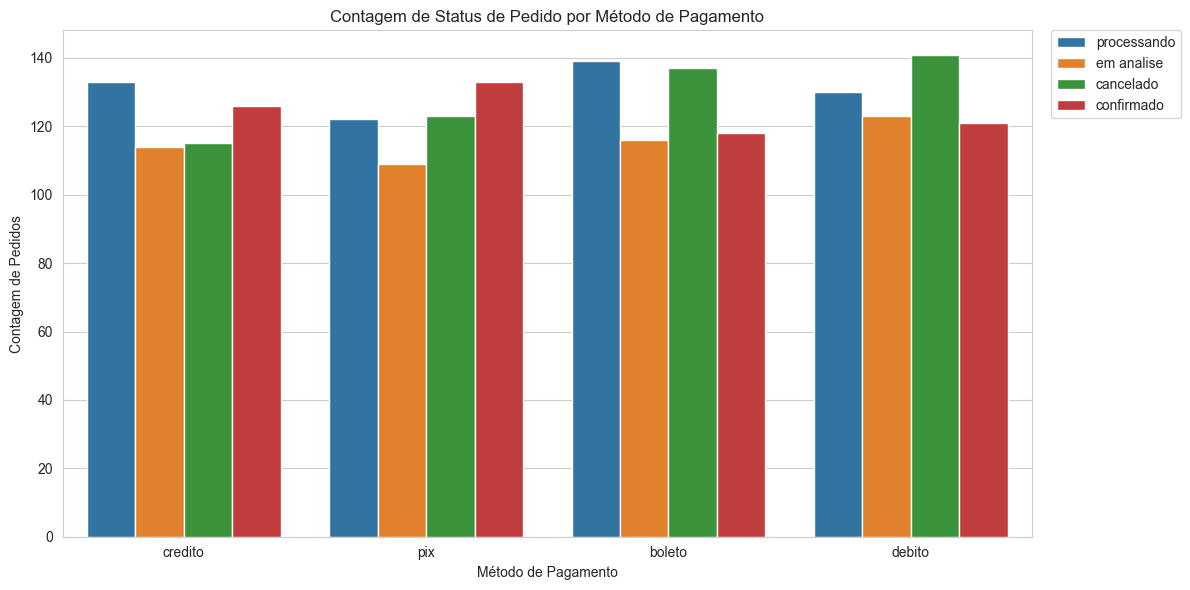

In [123]:

# 4. Análise de Pagamento e Conversão  

# Status de Pagamento por Método
plt.figure(figsize=(12, 6))
sns.countplot(data=df_abt, x='Payment_Method', hue='Purchase_Status')
plt.title('Contagem de Status de Pedido por Método de Pagamento')
plt.ylabel('Contagem de Pedidos')
plt.xlabel('Método de Pagamento')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()


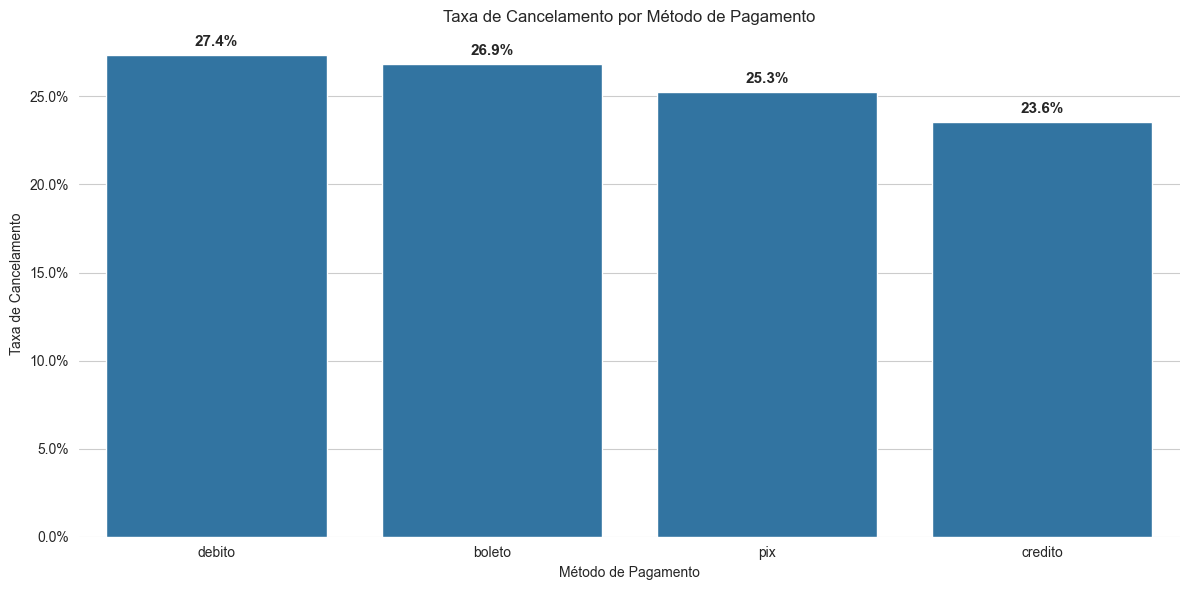

In [124]:

# Taxa de Cancelamento por Método de Pagamento
taxa_cancel_pagto = df_abt.groupby('Payment_Method')['is_canceled'].mean().reset_index()
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=taxa_cancel_pagto.sort_values('is_canceled', ascending=False), 
    x='Payment_Method', 
    y='is_canceled')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1%}', 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', 
        va='center', 
        xytext=(0, 9), 
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
plt.title('Taxa de Cancelamento por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Taxa de Cancelamento')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


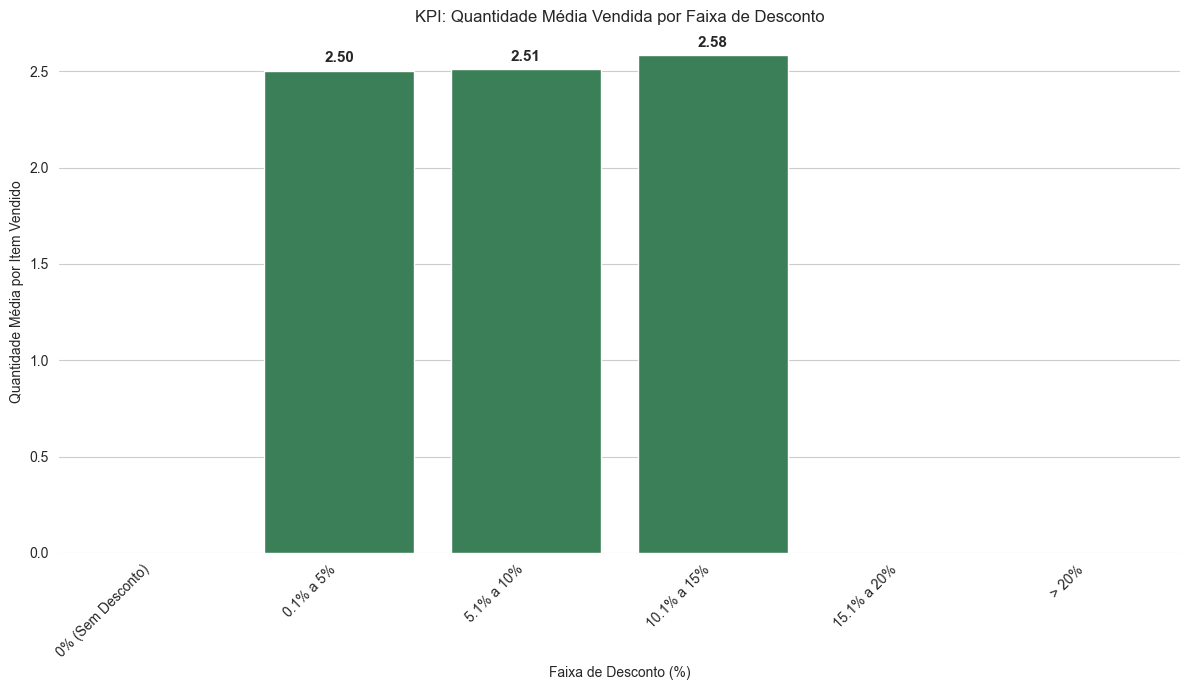

In [132]:
# Análise de Elasticidade de Preço (Desconto vs. Quantidade Vendida)

plt.figure(figsize=(12, 7))

# Usamos 'seagreen' como uma cor sugestiva (dinheiro)
ax = sns.barplot(
    data=kpi_elasticidade, 
    x='faixa_desconto', 
    y='Quantity',
    color='seagreen'
)

# Adicionar rótulos de dados
for p in ax.patches:
    height = p.get_height()
    # '{:.2f}' formata o número com 2 casas decimais (ex: "1.25")
    ax.annotate(
        f'{height:.2f}', 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', 
        va='center', 
        xytext=(0, 9), 
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

plt.title('KPI: Quantidade Média Vendida por Faixa de Desconto')
plt.xlabel('Faixa de Desconto (%)')
plt.ylabel('Quantidade Média por Item Vendido')
plt.xticks(rotation=45, ha='right')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


In [127]:
print("\n--- Iniciando Inferência Estatística ---")

def get_ic_mean(data, confidence=0.95):
    if len(data) < 2:
        return (np.nan, np.nan)
    n = len(data)
    mean = data.mean()
    sem = st.sem(data)
    ic = st.t.interval(confidence=confidence, df=n-1, loc=mean, scale=sem)
    return ic

# IC de Proporção (usando método 'wilson')
def get_ic_proportion(data, confidence=0.95):
    n_total = len(data)
    if n_total == 0:
        return (np.nan, np.nan)
    n_success = data.sum()
    ic = proportion_confint(count=n_success, nobs=n_total, alpha=(1-confidence), method='wilson')
    return ic

resultados_inferencia = {}

# 1. IC 95% para Ticket Médio
# Usamos apenas pedidos confirmados para o Ticket Médio
data_ticket = df_abt[df_abt['is_confirmed']==1]['Total']
ic_ticket = get_ic_mean(data_ticket)
resultados_inferencia['Ticket Medio'] = {
    'Média': data_ticket.mean(),
    'IC 95%': ic_ticket
}

# 2. IC 95% para Prazo Médio de Entrega
if not df_entregues.empty:
    data_prazo = df_entregues['delivery_lead_time_days']
    ic_prazo = get_ic_mean(data_prazo)
    resultados_inferencia['Prazo Médio Entrega (dias)'] = {
        'Média': data_prazo.mean(),
        'IC 95%': ic_prazo
    }

# 3. IC 95% para Taxa de Atraso (Geral)
if not df_entregues.empty:
    data_atraso = df_entregues['is_late']
    ic_atraso = get_ic_proportion(data_atraso)
    resultados_inferencia['Taxa de Atraso (Geral)'] = {
        'Proporção': data_atraso.mean(),
        'IC 95%': ic_atraso
    }

# 4. IC 95% para Taxa de Cancelamento (Geral)
data_cancel = df_abt['is_canceled']
ic_cancel = get_ic_proportion(data_cancel)
resultados_inferencia['Taxa de Cancelamento (Geral)'] = {
    'Proporção': data_cancel.mean(),
    'IC 95%': ic_cancel
}

# Tabela de Resultados
print("\n--- Resultados Finais: Intervalos de Confiança (95%) ---")
for kpi, values in resultados_inferencia.items():
    media_ou_prop = "Média" if "Média" in values else "Proporção"
    print(f"\nKPI: {kpi}")
    print(f"  {media_ou_prop}: {values[media_ou_prop]:.4f}")
    print(f"  IC 95%: ({values['IC 95%'][0]:.4f}, {values['IC 95%'][1]:.4f})")


--- Iniciando Inferência Estatística ---

--- Resultados Finais: Intervalos de Confiança (95%) ---

KPI: Ticket Medio
  Média: 2470.2302
  IC 95%: (2214.4935, 2725.9668)

KPI: Prazo Médio Entrega (dias)
  Média: 29.5758
  IC 95%: (27.8675, 31.2841)

KPI: Taxa de Atraso (Geral)
  Proporção: 0.8424
  IC 95%: (0.8186, 0.8636)

KPI: Taxa de Cancelamento (Geral)
  Proporção: 0.2580
  IC 95%: (0.2393, 0.2776)
